d:\anaconda\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\anaconda\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"



⚠️ [结构警告] 忽略损坏或无效的非标文件: VERSION.dcm | 原因: 该文件不包含有效的 PixelData 影像矩阵

⚠️ [结构警告] 忽略损坏或无效的非标文件: VERSION.dcm | 原因: 该文件不包含有效的 PixelData 影像矩阵
tra slice (Top-1)...


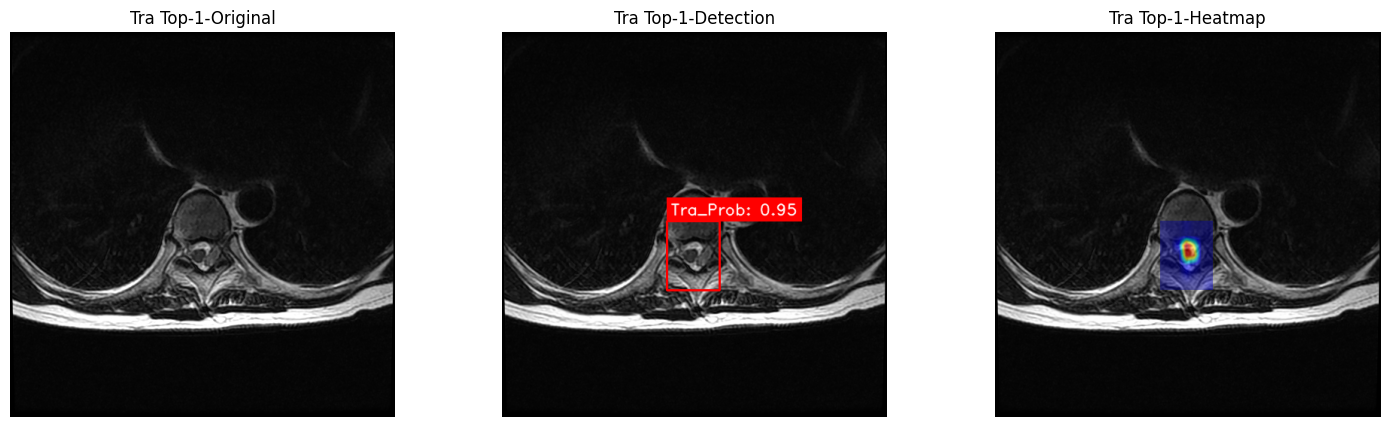

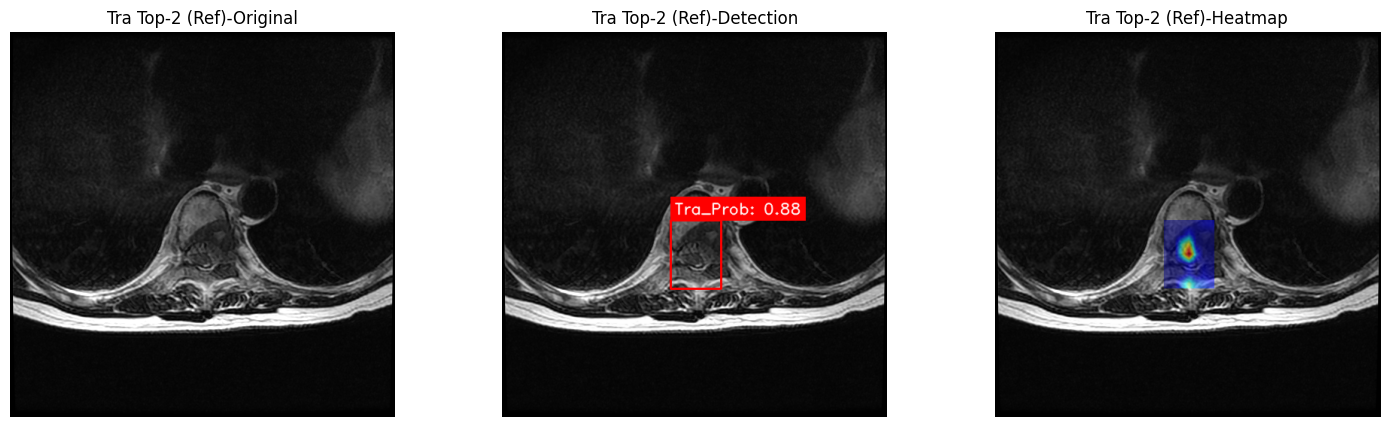

sag slice (Top 1 & 2)...


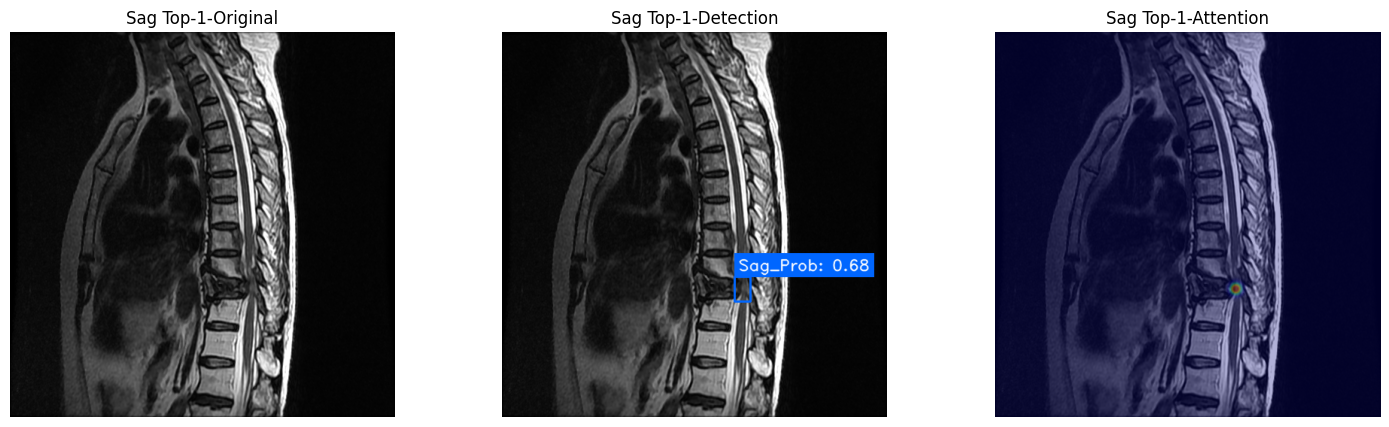

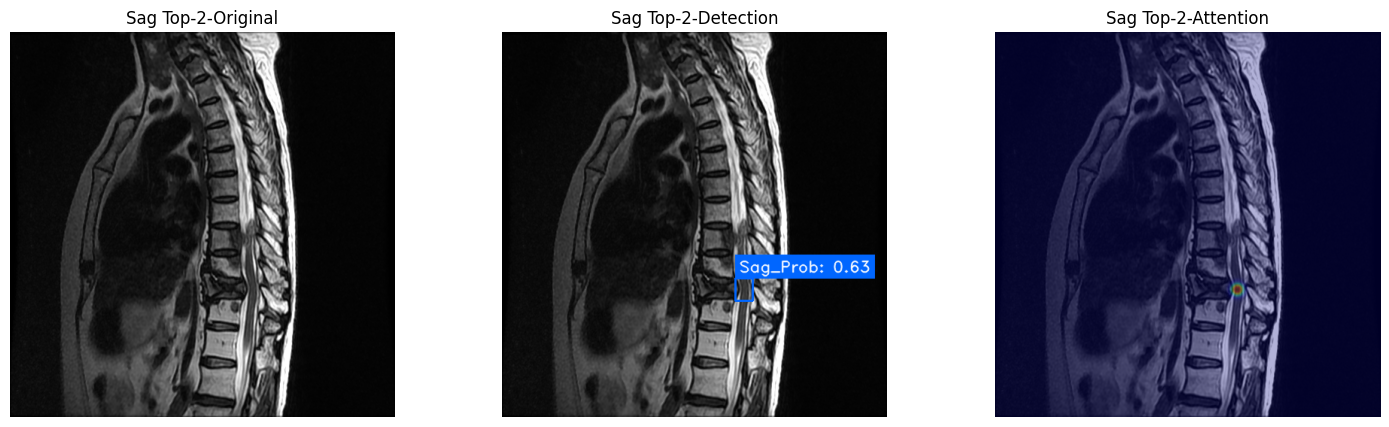


[ Logistic Regression SMCRAI Score Calculation ]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Positive. Risk score: 99.02%


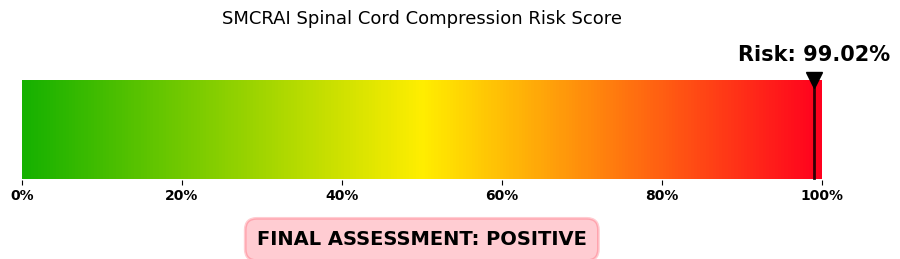

In [ ]:
# Dicom
import os
import torch
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from ultralytics import YOLO
from IPython.display import display, Math
import pydicom  
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Model Loading
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_pkg_path = r"C:\Users\ASUS\SpM\code submitted\logistic_lasso_3factors_convnext.pkl"
pkg = joblib.load(model_pkg_path)
logreg, scaler, features_in_pkg = pkg['model'], pkg['scaler'], pkg['features']

# RetinaNet
retina_model = models.detection.retinanet_resnet50_fpn(pretrained=False, num_classes=3).to(device)
retina_model.load_state_dict(torch.load(r"C:\Users\ASUS\SpM\code submitted\retinanet.pth"))
retina_model.eval()

# ConvNeXt_Tiny
convnext_model = models.convnext_tiny(pretrained=False)
convnext_model.classifier[2] = torch.nn.Linear(convnext_model.classifier[2].in_features, 2)
convnext_model.load_state_dict(torch.load(r"C:\Users\ASUS\SpM\code submitted\convnext.pth"))
convnext_model.to(device).eval()

# YOLOv8
yolo_model = YOLO(r"C:\Users\ASUS\SpM\code submitted\yolo.pt")

def read_single_dcm_uint8(dcm_path):
    try:
        ds = pydicom.dcmread(dcm_path, force=True)
        if not hasattr(ds, 'pixel_array'):
            raise AttributeError("该文件不包含有效的 PixelData 影像矩阵")
            
        image_data = ds.pixel_array.astype(float)
        
        p1 = np.percentile(image_data, 1)
        p99 = np.percentile(image_data, 99)
        
        image_data = np.clip(image_data, p1, p99)
        img_8bit = ((image_data - p1) / (p99 - p1 + 1e-8) * 255).astype(np.uint8)
        
        return img_8bit
        
    except Exception as e:
        print(f"\n⚠️ [结构警告] 忽略损坏或无效的非标文件: {os.path.basename(dcm_path)} | 原因: {e}")
        return np.zeros((512, 512), dtype=np.uint8)

# ==========================================
# 2. Functions for Tra & Sag
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = dict(model.named_modules())[target_layer]
        self.gradients, self.activation = None, None
        self.target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activation', o))
        self.target_layer.register_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0]))

    def generate(self, input_ts, class_idx):
        self.model.zero_grad()
        out = self.model(input_ts)
        out[:, class_idx].backward()
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activation, dim=1).squeeze().detach().cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (input_ts.shape[3], input_ts.shape[2]))
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def get_tra_inference(dcm_path):
    img_array = read_single_dcm_uint8(dcm_path)
    input_ts = TF.to_tensor(img_array).unsqueeze(0).to(device)
    with torch.no_grad():
        det = retina_model(input_ts)[0]
    if len(det['scores']) > 0:
        idx = torch.argmax(det['scores'])
        bbox = det['boxes'][idx].cpu().numpy().astype(int)
        roi = img_array[bbox[1]:bbox[3], bbox[0]:bbox[2]]
        
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_GRAY2RGB)
        roi_pil = PILImage.fromarray(roi_rgb)
        roi_ts = transforms.Compose([
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])(roi_pil).unsqueeze(0).to(device)
        
        roi_ts.requires_grad = True
        logits = convnext_model(roi_ts)
        prob = torch.softmax(logits, dim=1)[0, 1].item()
        cam = GradCAM(convnext_model, "features.7").generate(roi_ts, 1)
        return prob, bbox, img_array, cam
    return 0.0, None, img_array, None

# ==========================================
# 3. Visualization
# ==========================================
def draw_custom_box(img, bbox, prob, label_prefix, bg_color):
    canvas = img.copy()
    if img.ndim == 2: canvas = cv2.cvtColor(canvas, cv2.COLOR_GRAY2RGB)
    xmin, ymin, xmax, ymax = map(int, bbox)
    
    cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), bg_color, 2)
    display_text = f"{label_prefix}_Prob: {prob:.2f}"
    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 1
    (tw, th), _ = cv2.getTextSize(display_text, font, font_scale, thickness)
    
    bg_ymin = ymin - th - 15
    bg_ymax = ymin
    text_y = ymin - 8
    if bg_ymin < 0:
        bg_ymin = ymax
        bg_ymax = ymax + th + 15
        text_y = ymax + th + 8
        
    cv2.rectangle(canvas, (xmin, bg_ymin), (xmin + tw + 10, bg_ymax), bg_color, -1)
    cv2.putText(canvas, display_text, (xmin + 5, text_y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
    return canvas

def show_tra_top(data, title):
    if data.get('bbox') is None: return
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(data['orig'], cmap='gray'); axes[0].axis('off'); axes[0].set_title(f'{title}-Original')
    det_img = draw_custom_box(data['orig'], data['bbox'], data['prob'], "Tra", (255, 0, 0))
    axes[1].imshow(det_img); axes[1].axis('off'); axes[1].set_title(f'{title}-Detection')
    xmin, ymin, xmax, ymax = data['bbox']
    cam_resized = cv2.resize(1 - data['cam'], (xmax-xmin, ymax-ymin))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    roi_rgb = np.repeat((data['orig'][ymin:ymax, xmin:xmax]/255.0)[:, :, np.newaxis], 3, axis=2)
    overlay = (np.float32(heatmap)/255.0 + np.float32(roi_rgb)); overlay /= np.max(overlay)
    full_img = cv2.cvtColor(data['orig'], cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
    full_img[ymin:ymax, xmin:xmax] = overlay
    axes[2].imshow(np.clip(full_img, 0, 1)); axes[2].axis('off'); axes[2].set_title(f'{title}-Heatmap')
    plt.show()

def show_sag_top(data, title):
    if data.get('path') is None: return
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    img_uint8 = read_single_dcm_uint8(data['path'])
    img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
    
    axes[0].imshow(img_rgb); axes[0].axis('off'); axes[0].set_title(f'{title}-Original')
    if len(data['res'].boxes) > 0:
        box = data['res'].boxes[0].xyxy[0].cpu().numpy().astype(int)
        det_img = draw_custom_box(img_rgb, box, data['prob'], "Sag", (0, 102, 255))
    else: det_img = img_rgb
    axes[1].imshow(det_img); axes[1].axis('off'); axes[1].set_title(f'{title}-Detection')
    
    h, w = img_rgb.shape[:2]; heatmap = np.zeros((h, w), dtype=np.float32)
    if len(data['res'].boxes) > 0:
        b = data['res'].boxes[0].xyxy[0].cpu().numpy().astype(int)
        y, x = np.ogrid[:h, :w]; heatmap = np.exp(-((x-(b[0]+b[2])//2)**2 + (y-(b[1]+b[3])//2)**2) / (2*(min(b[2]-b[0], b[3]-b[1])/4)**2))
    heatmap_rgb = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb.astype(np.float32), 0.7, heatmap_rgb.astype(np.float32), 0.3, 0)
    axes[2].imshow(np.clip(overlay/255.0, 0, 1)); axes[2].axis('off'); axes[2].set_title(f'{title}-Attention')
    plt.show()

# ==========================================
# 4. Individual Scan & Visualization
# ==========================================
patient_dir = r"D:\MED\SpM\external validation\GDP_SpM\MR201903230124"  # the folder containing "tra" and "sag" subfolders with DICOM files
tra_path, sag_path = os.path.join(patient_dir, "tra"), os.path.join(patient_dir, "sag")

# tra
tra_list = []
for f in [x for x in os.listdir(tra_path) if x.lower().endswith('.dcm')]:
    p, b, orig, c = get_tra_inference(os.path.join(tra_path, f))
    tra_list.append({'prob': p, 'bbox': b, 'orig': orig, 'cam': c, 'name': f})
tra_top = sorted(tra_list, key=lambda x: x['prob'], reverse=True) + [{'prob': 0.0}] * 2

# sag
sag_list = []
for f in [x for x in os.listdir(sag_path) if x.lower().endswith('.dcm')]:
    full_path = os.path.join(sag_path, f)
    img_uint8 = read_single_dcm_uint8(full_path)
    img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
    
    res = yolo_model.predict(img_rgb, verbose=False)[0]
    score = res.boxes.conf.max().item() if len(res.boxes) > 0 else 0.0
    sag_list.append({'prob': score, 'res': res, 'path': full_path})
sag_top = sorted(sag_list, key=lambda x: x['prob'], reverse=True) + [{'prob': 0.0}] * 2 

# show
print("tra slice (Top-1)...")
show_tra_top(tra_top[0], "Tra Top-1")
show_tra_top(tra_top[1], "Tra Top-2 (Ref)")

print("sag slice (Top 1 & 2)...")
show_sag_top(sag_top[0], "Sag Top-1")
show_sag_top(sag_top[1], "Sag Top-2")

# ==========================================
# 5. SMCRAI score
# ==========================================
x_in = np.array([[tra_top[0]['prob'], sag_top[0]['prob'], sag_top[1]['prob']]])

x_std = scaler.transform(x_in)
p_final = logreg.predict_proba(x_std)[0, 1]

intercept = logreg.intercept_[0]
coeffs = logreg.coef_[0]
means = scaler.mean_
stds = scaler.scale_

z_parts = [f"{intercept:.4f}"]
for i, feat in enumerate(features_in_pkg):
    symbol = "+" if coeffs[i] >= 0 else "-"
    clean_name = "\\text{" + feat.replace('_', '\\_') + "}"
    part = f" {symbol} {abs(coeffs[i]):.4f} \\cdot \\left( \\frac{{{clean_name} - {means[i]:.4f}}}{{{stds[i]:.4f}}} \\right)"
    z_parts.append(part)

print("\n" + "="*80)
print("[ Logistic Regression SMCRAI Score Calculation ]")  
display(Math("z = " + "".join(z_parts)))
display(Math(r"P(\text{Compression}) = \frac{1}{1 + e^{-z}} = " + f"{p_final:.4f}"))

if p_final > 0.5:
    print(f"Positive. Risk score: {p_final:.2%}")
else:
    print(f"Negative. Risk score: {p_final:.2%}")

# ==========================================
# 6. Risk Gauge
# ==========================================
def show_risk_gauge_gradient(prob):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    plt.subplots_adjust(left=0.1, right=0.9, top=0.7, bottom=0.3)
    colors = ["#15b100", "#ffee00", "#ff001e"]
    cmap = mcolors.LinearSegmentedColormap.from_list("risk_cmap", colors)
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap=cmap, extent=[0, 1, 0, 1], zorder=0)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=10, fontweight='bold')
    ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.axvline(x=prob, color='black', linestyle='-', linewidth=2, alpha=0.8, zorder=1)
    ax.plot(prob, 1, marker='v', color='black', markersize=12, clip_on=False, zorder=2)
    final_color = cmap(prob) 
    status_text = "POSITIVE" if prob > 0.5 else "NEGATIVE"
    plt.text(prob, 1.15, f'Risk: {prob:.2%}', color='black', ha='center', va='bottom', fontsize=15, fontweight='black')
    plt.text(0.5, -0.6, f"FINAL ASSESSMENT: {status_text}", ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(facecolor=final_color, alpha=0.2, edgecolor=final_color, boxstyle='round,pad=0.6', linewidth=2))
    plt.title("SMCRAI Spinal Cord Compression Risk Score", fontsize=13, pad=40, color="#000000")
    ax.patch.set_facecolor('white'); ax.set_zorder(1)
    plt.show()

import matplotlib.colors as mcolors
show_risk_gauge_gradient(p_final)